### 1 - 1

В датасете /datasets/game_purchases.csv записаны данные о покупках, совершённых внутри мобильной стратегической игры «Крэш оф Крэнс». 

В столбцах таблицы:

purchase_datetime — дата и время покупки;

player_id — уникальный идентификатор игрока;

item — название купленной игровой единицы: life (англ. «жизнь»), mana (англ. «магическая сила», в играх — «топливо» для заклинаний), armour (англ. «броня»);

price — цена во внутриигровой валюте;

purchase_id — уникальный идентификатор покупки.

Прочитайте данные из файла game_purchases.csv. Результат сохраните в переменной purchases.

Сгруппируйте данные таблицы purchases: для каждого игрока найдите дату его первой покупки. Полученный объект Series назовите first_purchase_dates.
Переименуйте объект Series в first_purchase_datetime, изменив атрибут name.

Выведите первые 10 строк first_purchase_dates.

In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [78]:
purchases = pd.read_csv('./game_purchases.csv')
purchases.head()

,purchase_datetime,player_id,item,price,purchase_id
0,2019-01-01 00:15:54,2434d4ef-7949-4311-a9e6-9263e2ea2b7c,armour,0.1,10423
1,2019-01-01 00:16:56,1ecd854d-f707-44a2-b174-0c0039668650,life,0.3,10424
2,2019-01-01 00:56:17,1156b1a0-732b-4732-ab41-79f77cd0e719,life,0.3,10425
3,2019-01-01 00:58:17,1f7b30f3-26ac-45bd-82b4-30fad1d1398d,armour,0.1,10426
4,2019-01-01 01:15:42,4697efd3-15b2-4f40-84fb-7e5c65e390c9,armour,0.1,10427


In [79]:
first_purchase_dates = purchases.groupby('player_id')['purchase_datetime'].min()
first_purchase_dates.name = 'first_purchase_datetime'
first_purchase_dates.head(10)

player_id
00065bd9-5355-4c4b-b331-e8dcb74c18dc    2019-03-16 12:34:54
00209bef-ccb4-44d1-b385-7a7a006b81a9    2019-01-06 01:51:41
0024571d-3a4a-4664-858c-ac4317205892    2019-05-23 03:13:15
00369580-9fbf-4f2f-b3bf-60b18aacdb32    2019-03-04 19:05:45
003a9684-be82-4b7e-a176-4cc8a6beb6fe    2019-01-14 21:48:20
004b5aaa-1881-49e4-8d1c-79182f7181cb    2019-01-14 11:08:05
00557d31-77ed-4f77-90e7-99b0cb7be674    2019-01-14 10:32:20
00658dc0-ee2d-4831-9c86-9c9ebdaa0ccc    2019-01-07 22:47:55
00959130-8b4a-4ba0-8a7d-29b3469e5a1d    2019-01-23 11:13:10
009fa280-fe17-40f7-868c-0a10394addb3    2019-04-22 08:21:04
Name: first_purchase_datetime, dtype: object

### 1 - 2

Объедините датафрейм purchases и объект Series first_purchase_dates так, чтобы first_purchase_dates стал отдельным столбцом датафрейма purchases.

Сохраните объединённый датафрейм в переменной purchases.

Выведите первые 10 строк объединённого датафрейма.

In [80]:
first_purchase_dates = pd.to_datetime(first_purchase_dates)

In [81]:
purchases = purchases.join(first_purchase_dates, on = 'player_id')

In [82]:
purchases.head()

,purchase_datetime,player_id,item,price,purchase_id,first_purchase_datetime
0,2019-01-01 00:15:54,2434d4ef-7949-4311-a9e6-9263e2ea2b7c,armour,0.1,10423,2019-01-01 00:15:54
1,2019-01-01 00:16:56,1ecd854d-f707-44a2-b174-0c0039668650,life,0.3,10424,2019-01-01 00:16:56
2,2019-01-01 00:56:17,1156b1a0-732b-4732-ab41-79f77cd0e719,life,0.3,10425,2019-01-01 00:56:17
3,2019-01-01 00:58:17,1f7b30f3-26ac-45bd-82b4-30fad1d1398d,armour,0.1,10426,2019-01-01 00:58:17
4,2019-01-01 01:15:42,4697efd3-15b2-4f40-84fb-7e5c65e390c9,armour,0.1,10427,2019-01-01 01:15:42


### 1 - 3

В датафрейме purchases создайте столбец purchase_month, в котором сохраните месяц, извлечённый из значений столбца purchase_datetime.

Также в датафрейме purchases создайте столбец first_purchase_month, в котором сохраните месяц, извлечённый из значений столбца first_purchase_datetime. Этот столбец будет когортой.


Выведите первые 10 строк датафрейма purchases.

In [83]:
purchases.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16666 entries, 0 to 16665
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   purchase_datetime        16666 non-null  object        
 1   player_id                16666 non-null  object        
 2   item                     16666 non-null  object        
 3   price                    16666 non-null  float64       
 4   purchase_id              16666 non-null  int64         
 5   first_purchase_datetime  16666 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 781.3+ KB


In [84]:
purchases['purchase_datetime'] = pd.to_datetime(purchases['purchase_datetime'])

In [85]:
purchases['purchase_month'] = purchases['purchase_datetime'].dt.month
purchases['first_purchase_month'] = purchases['first_purchase_datetime'].dt.month

In [86]:
purchases.head(10)

,purchase_datetime,player_id,item,price,purchase_id,first_purchase_datetime,purchase_month,first_purchase_month
0,2019-01-01 00:15:54,2434d4ef-7949-4311-a9e6-9263e2ea2b7c,armour,0.1,10423,2019-01-01 00:15:54,1,1
1,2019-01-01 00:16:56,1ecd854d-f707-44a2-b174-0c0039668650,life,0.3,10424,2019-01-01 00:16:56,1,1
2,2019-01-01 00:56:17,1156b1a0-732b-4732-ab41-79f77cd0e719,life,0.3,10425,2019-01-01 00:56:17,1,1
3,2019-01-01 00:58:17,1f7b30f3-26ac-45bd-82b4-30fad1d1398d,armour,0.1,10426,2019-01-01 00:58:17,1,1
4,2019-01-01 01:15:42,4697efd3-15b2-4f40-84fb-7e5c65e390c9,armour,0.1,10427,2019-01-01 01:15:42,1,1
5,2019-01-01 01:16:46,8e5d5901-b6eb-4c47-9a35-21878d0a25ba,mana,0.2,10428,2019-01-01 01:16:46,1,1
6,2019-01-01 01:24:40,060a1cee-8346-478f-b7ea-0286392512b3,life,0.3,10429,2019-01-01 01:24:40,1,1
7,2019-01-01 01:43:49,4763379d-d3cb-4536-927b-07f9a004d523,mana,0.2,10430,2019-01-01 01:43:49,1,1
8,2019-01-01 01:48:47,0f8cc412-1e70-40f4-9f2d-40a65f943378,mana,0.2,10431,2019-01-01 01:48:47,1,1
9,2019-01-01 01:51:21,7e055271-dcd5-450c-bf32-919d5e21cc9b,life,0.3,10432,2019-01-01 01:51:21,1,1


### 1 - 4

Из датафрейма purchases сформируйте таблицу, где для каждой когорты подсчитайте сумму, на которую были сделаны внутриигровые покупки.

Сохраните сгруппированную таблицу в переменной cohort_stats.

Выведите таблицу cohort_stats.

In [87]:
cohort_stats = purchases.groupby('first_purchase_month')['price'].sum()
cohort_stats

first_purchase_month
1    2432.2
2     602.5
3     292.7
4     192.8
5     108.5
6      72.8
7      46.7
Name: price, dtype: float64

### 2 - 1

Сохраните в переменной purchase_pivot сводную таблицу, которая отражала бы изменение общей стоимости покупок, совершённых игроками, в когортах по месяцам.

Выведите сводную таблицу.

In [88]:
purchase_pivot =  purchases.pivot_table(index='first_purchase_month',columns='purchase_month', values='price')
purchase_pivot

purchase_month,1,2,3,4,5,6,7
first_purchase_month,,,,,,,
1,0.221619,0.226642,0.224401,0.223892,0.222120,0.224928,0.226022
2,NaN,0.228259,0.230149,0.233231,0.229379,0.225000,0.229799
3,NaN,NaN,0.228145,0.227389,0.228235,0.220231,0.230263
4,NaN,NaN,NaN,0.223000,0.214074,0.212613,0.211765
5,NaN,NaN,NaN,NaN,0.229775,0.204762,0.219048
6,NaN,NaN,NaN,NaN,NaN,0.228625,0.235417
7,NaN,NaN,NaN,NaN,NaN,NaN,0.226699


### 2 - 2

Сохраните в переменной purchases_grouped_by_cohorts датафрейм, где для каждой когорты игроков и каждого месяца найдите число покупок и количество игроков, совершивших покупки.

Добавьте в датафрейм purchases_grouped_by_cohorts столбец purchases_per_player, в котором рассчитайте среднее количество покупок на игрока.

Сформируйте и сохраните в переменной mean_purchases_pivot сводную таблицу, в которой отразите изменение среднего количества покупок на игрока по когортам в различных месяцах.

Выведите сводную таблицу mean_purchases_pivot.

In [89]:
purchases_grouped_by_cohorts = purchases.groupby(['first_purchase_month', 'purchase_month']).agg({'purchase_id': 'nunique', 'player_id': 'nunique'})
purchases_grouped_by_cohorts

purchase_id  player_id
first_purchase_month purchase_month                        
1                    1                      2507       1500
                     2                      1340        655
                     3                      1418        686
                     4                      1444        663
                     5                      1415        662
                     6                      1392        696
                     7                      1345        664
2                    2                       959        763
                     3                       335        230
                     4                       325        239
                     5                       354        260
                     6                       308        226
                     7                       349        252
3                    3                       636        541
                     4                       157        126
                     5                       170        131
                     6                       173        130
                     7                       152        118
4                    4                       500        435
                     5                       135        103
                     6                       111         91
                     7                       136        103
5                    5                       356        328
                     6                        63         55
                     7                        63         54
6                    6                       269        241
                     7                        48         41
7                    7                       206        192

In [90]:
purchases_grouped_by_cohorts['purchases_per_player'] = (purchases_grouped_by_cohorts['purchase_id']/purchases_grouped_by_cohorts['player_id'])
purchases_grouped_by_cohorts

purchase_id  player_id  \
first_purchase_month purchase_month                           
1                    1                      2507       1500   
                     2                      1340        655   
                     3                      1418        686   
                     4                      1444        663   
                     5                      1415        662   
                     6                      1392        696   
                     7                      1345        664   
2                    2                       959        763   
                     3                       335        230   
                     4                       325        239   
                     5                       354        260   
                     6                       308        226   
                     7                       349        252   
3                    3                       636        541   
                     4                       157        126   
                     5                       170        131   
                     6                       173        130   
                     7                       152        118   
4                    4                       500        435   
                     5                       135        103   
                     6                       111         91   
                     7                       136        103   
5                    5                       356        328   
                     6                        63         55   
                     7                        63         54   
6                    6                       269        241   
                     7                        48         41   
7                    7                       206        192   

                                     purchases_per_player  
first_purchase_month purchase_month                        
1                    1                           1.671333  
                     2                           2.045802  
                     3                           2.067055  
                     4                           2.177979  
                     5                           2.137462  
                     6                           2.000000  
                     7                           2.025602  
2                    2                           1.256881  
                     3                           1.456522  
                     4                           1.359833  
                     5                           1.361538  
                     6                           1.362832  
                     7                           1.384921  
3                    3                           1.175601  
                     4                           1.246032  
                     5                           1.297710  
                     6                           1.330769  
                     7                           1.288136  
4                    4                           1.149425  
                     5                           1.310680  
                     6                           1.219780  
                     7                           1.320388  
5                    5                           1.085366  
                     6                           1.145455  
                     7                           1.166667  
6                    6                           1.116183  
                     7                           1.170732  
7                    7                           1.072917

In [94]:
mean_purchases_pivot  = purchases_grouped_by_cohorts.pivot_table( index='first_purchase_month',columns='purchase_month', values='purchases_per_player', aggfunc='mean',)
mean_purchases_pivot # Выведите сводную таблицу

purchase_month,1,2,3,4,5,6,7
first_purchase_month,,,,,,,
1,1.671333,2.045802,2.067055,2.177979,2.137462,2.000000,2.025602
2,NaN,1.256881,1.456522,1.359833,1.361538,1.362832,1.384921
3,NaN,NaN,1.175601,1.246032,1.297710,1.330769,1.288136
4,NaN,NaN,NaN,1.149425,1.310680,1.219780,1.320388
5,NaN,NaN,NaN,NaN,1.085366,1.145455,1.166667
6,NaN,NaN,NaN,NaN,NaN,1.116183,1.170732
7,NaN,NaN,NaN,NaN,NaN,NaN,1.072917


### 2 - 3

Создайте в таблице purchases_grouped_by_cohorts столбец cohort_lifetime. В нём месяц внутриигровой покупки purchase_month преобразуйте в lifetime, или порядковый месяц относительно месяца первой покупки.

Столбец cohort_lifetime должен содержать целое число.

Это задача с промежуточным решением. Ничего не нужно выводить на экран.

In [96]:
purchases_grouped_by_cohorts = purchases_grouped_by_cohorts.reset_index()
# Преобразуем purchase_month и first_purchase_month в datetime, если они еще не в этом формате
purchases_grouped_by_cohorts['purchase_month'] = pd.to_datetime(purchases_grouped_by_cohorts['purchase_month'])
purchases_grouped_by_cohorts['first_purchase_month'] = pd.to_datetime(purchases_grouped_by_cohorts['first_purchase_month'])

# Создадим новый столбец cohort_lifetime
purchases_grouped_by_cohorts['cohort_lifetime'] = (
    (purchases_grouped_by_cohorts['purchase_month'].dt.year - purchases_grouped_by_cohorts['first_purchase_month'].dt.year) * 12 +
    (purchases_grouped_by_cohorts['purchase_month'].dt.month - purchases_grouped_by_cohorts['first_purchase_month'].dt.month) + 1
).astype(int)

### 2 - 4

Постройте и сохраните в переменной lifetime_pivot сводную таблицу, которая для каждой когорты покажет изменение среднего количества покупок игрока в зависимости от lifetime игрока в когорте.

Выведите lifetime_pivot.

In [100]:
lifetime_pivot = purchases_grouped_by_cohorts.pivot_table(index='first_purchase_month', columns='cohort_lifetime',values='purchases_per_player',aggfunc='mean')
lifetime_pivot

cohort_lifetime,1
first_purchase_month,
1970-01-01 00:00:00.000000001,2.017891
1970-01-01 00:00:00.000000002,1.363754
1970-01-01 00:00:00.000000003,1.267649
1970-01-01 00:00:00.000000004,1.250068
1970-01-01 00:00:00.000000005,1.132496
1970-01-01 00:00:00.000000006,1.143457
1970-01-01 00:00:00.000000007,1.072917


### 3 - 1

В датафрейме revenue_per_user_pivot  сводная таблица, отражающая изменение среднего чека покупателей интернет-магазина спортивных товаров «О, спорт! Ты — спорт!» по когортам в зависимости от lifetime. Методом heatmap() создайте тепловую карту изменения среднего чека по когортам.

Задайте величину фигуры: plt.figure(figsize=(13, 9)).

Назовите визуализацию 'Средний чек покупателей'.

Методу heatmap() передайте параметры annot, fmt, linewidths и linecolor так, чтобы:

величина отображалась в ячейках тепловой карты;

выводились два знака после запятой;

линия, разграничивающая ячейки, была шириной в 1 пиксель;

цвет линии был чёрным ('black').

In [102]:
revenue_per_user_pivot = pd.read_csv('./revenue_pivot.csv')
revenue_per_user_pivot = revenue_per_user_pivot.set_index('first_order_month')

<Axes: title={'center': 'Средний чек покупателей'}, ylabel='first_order_month'>

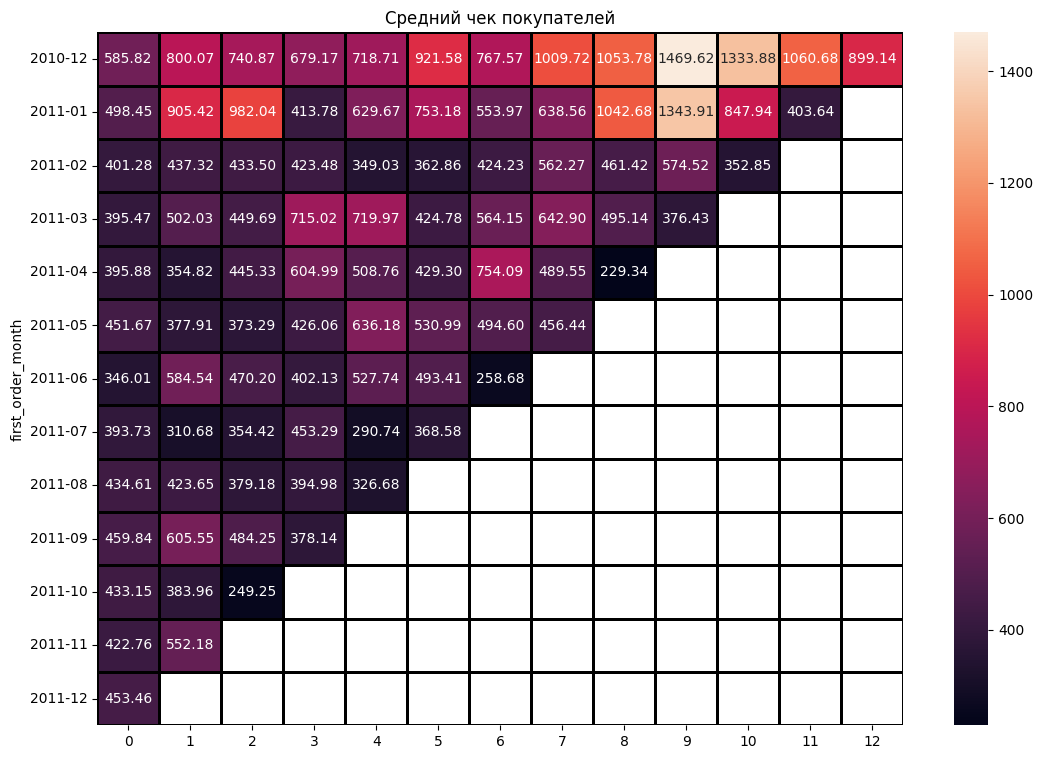

In [103]:
plt.figure(figsize=(13, 9))
plt.title('Средний чек покупателей')
# Создайте тепловую карту
sns.heatmap(revenue_per_user_pivot, annot=True,fmt='.2f',linewidths=1, linecolor='black')

### 4 - 1

В датафрейме work_user_activity данные об активности пользователей в мобильном приложении знакомств для интровертов «Финдер». В нём такие столбцы:

В first_activity_date дата, когда пользователь впервые написал понравившемуся человеку;

В activity_date все даты, когда пользователь писал этому адресату;

В user_id идентификатор пользователя.

Создайте в датафрейме user_activity два столбца:

activity_week с неделей, когда был начат диалог;

first_activity_week с неделей, когда диалог был начат впервые.

Получите порядковый номер дня недели так: (user_activity['activity_date'].dt.dayofweek, unit='d').

Выводить на экран ничего не нужно.

In [108]:

user_activity = pd.read_csv('./work_user_activity.csv')
user_activity['activity_date'] = pd.to_datetime(user_activity['activity_date'])
first_activity_date = user_activity.groupby(['user_id'])['activity_date'].min()
first_activity_date.name = 'first_activity_date'
user_activity = user_activity.join(first_activity_date, on='user_id')
user_activity['activity_week'] = pd.to_datetime(
    user_activity['activity_date'], unit='d'
) - pd.to_timedelta(user_activity['activity_date'].dt.dayofweek, unit='d')

user_activity['first_activity_week'] = pd.to_datetime(
    user_activity['first_activity_date'], unit='d'
) - pd.to_timedelta(
    user_activity['first_activity_date'].dt.dayofweek, unit='d'
)

### 4 - 2

Создайте в датафрейме user_activity столбец cohort_lifetime. Сохраните в нём целое количество недель, прошедших между неделей начатого диалога activity_week и неделей первого начатого диалога first_activity_week.

In [109]:
user_activity['cohort_lifetime'] = (user_activity['activity_week'] - user_activity['first_activity_week'])
user_activity['cohort_lifetime'] =  user_activity['cohort_lifetime'] / np.timedelta64(1, 'W')

user_activity['cohort_lifetime'] = user_activity['cohort_lifetime'].astype('int')

### 4 - 3

Решите задачу в 6 действий:

Создайте датафрейм cohorts, в котором будут следующие столбцы:

Столбец first_activity_week содержит когорту, сформированную на основе недели первого события пользователя;

Столбец cohort_lifetime содержит lifetime в неделях — порядковый номер относительно недели первого события;

В столбце user_id количество активных пользователей.

Создайте датафрейм initial_users_count, в котором для каждой когорты будет отображено число пользователей на нулевую неделю lifetime. Оставьте в этом датафрейме только следующие столбцы:

Неделю когорты — first_activity_week;

Количество активных пользователей — user_id.

Переименуйте в датафрейме initial_users_count столбец user_id в cohort_users. Он сохранит исходное число пользователей в когорте.

Объедините датафрейм cohorts и initial_users_count по столбцу с неделями когорты и сохраните результат в cohorts.

Рассчитайте показатель Retention Rate в столбце retention.

Выведите сводную таблицу retention_pivot, которая отобразит изменение retention по когортам first_activity_week в зависимости от lifetime.

In [110]:
cohorts = user_activity.groupby(['first_activity_week', 'cohort_lifetime']).agg({'user_id': 'nunique'}).reset_index()
initial_users_count = cohorts[cohorts['cohort_lifetime'] == 0][['first_activity_week', 'user_id']]

initial_users_count = initial_users_count.rename(columns={'user_id' : 'cohort_users'})
cohorts = cohorts.merge(initial_users_count, on ='first_activity_week')

cohorts['retention'] = cohorts['user_id'] / cohorts['cohort_users']

### 5 - 1

В файле churn_rate.csv содержатся данные о когортах мобильной игры «Моя оборона»:

users_count — количество пользователей в когорте.

lifetime — неделя lifetime когорты;

first_event_week — неделя когорты;

Загрузите данные из файла /datasets/churn_rate.csv в датафрейм cohorts.

Выведите первые 10 строк датафрейма cohorts.

In [111]:
cohorts = pd.read_csv('./churn_rate.csv')
cohorts.head(10)

,first_event_week,lifetime,users_count
0,2019-05-06,0,20
1,2019-05-06,1,8
2,2019-05-06,2,5
3,2019-05-06,3,7
4,2019-05-06,4,5
5,2019-05-06,5,6
6,2019-05-06,6,8
7,2019-05-06,7,4
8,2019-05-13,0,75
9,2019-05-13,1,23


### 5 - 2

В датафрейме cohorts создайте столбец churn_rate, в котором рассчитайте показатель Churn Rate по когортам.

Выведите первые 10 строк датафрейма.

In [112]:
cohorts['churn_rate']=cohorts.groupby(['first_event_week'])['users_count'].pct_change()
cohorts.head()

,first_event_week,lifetime,users_count,churn_rate
0,2019-05-06,0,20,NaN
1,2019-05-06,1,8,-0.600000
2,2019-05-06,2,5,-0.375000
3,2019-05-06,3,7,0.400000
4,2019-05-06,4,5,-0.285714


### 5 - 3

Создайте сводную таблицу churn_pivot, где в строках будет когорта, в столбцах lifetime, а значениями станут показатели Churn Rate.

Выведите сводную таблицу.

In [113]:
churn_pivot = cohorts.pivot_table(index='first_event_week', columns='lifetime', values='churn_rate', aggfunc='sum')
churn_pivot

lifetime,0,1,2,3,4,5,6,7
first_event_week,,,,,,,,
2019-05-06,0.0,-0.600000,-0.375000,0.400000,-0.285714,0.200000,0.333333,-0.5
2019-05-13,0.0,-0.693333,0.217391,-0.178571,0.173913,-0.074074,0.240000,NaN
2019-05-20,0.0,-0.658824,-0.034483,0.535714,-0.302326,0.133333,NaN,NaN
2019-05-27,0.0,-0.426087,-0.333333,0.113636,-0.163265,NaN,NaN,NaN
2019-06-03,0.0,-0.425000,-0.010870,-0.098901,NaN,NaN,NaN,NaN
2019-06-10,0.0,-0.352564,-0.079208,NaN,NaN,NaN,NaN,NaN
2019-06-17,0.0,-0.326316,NaN,NaN,NaN,NaN,NaN,NaN
2019-06-24,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 5 - 4

Cоздайте тепловую карту изменения среднего чека по когортам на основе churn_pivot.

Задайте величину фигуры: plt.figure(figsize=(13, 9)). Назовите визуализацию 'Churn Rate'.

Задайте параметры метода для построения тепловой карты так, чтобы:

величина отображалась в ячейках тепловой карты;

выводились процентные значения с одним знаком после запятой;

линия, разграничивающая ячейки, была шириной в 1 пиксель;

цвет линии был чёрным ('black').

<Axes: title={'center': 'Churn Rate'}, xlabel='lifetime', ylabel='first_event_week'>

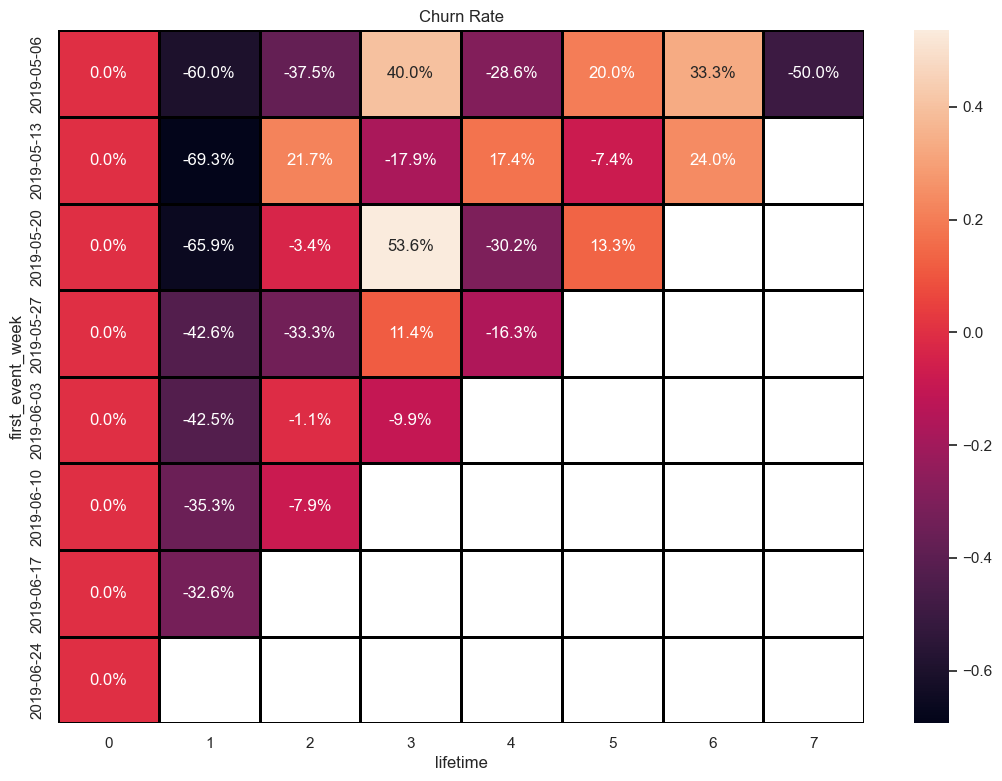

In [114]:
sns.set(style='white')
plt.figure(figsize=(13,9))
plt.title('Churn Rate')
sns.heatmap(churn_pivot, annot=True, fmt='.1%', linewidths=1, linecolor='black')

### 6 - 1

В файле /datasets/coffee_home.csv данные приложения кофейни «КофеХоум»:

coffee_time — время покупки кофе;

user_id — идентификатор клиента;

first_coffee_datetime — время покупки первого кофе (на основе этого параметра строится когорта first_coffee_week);

order_id — идентификатор покупки кофе;

coffee_week — неделя покупки кофе;

first_coffee_week — неделя покупки первого кофе (недельная когорта);

cohort_lifetime — lifetime клиента в рамках когорты.

В приложении посетители кафе отмечают покупку кофе на кассе. «КофеХоум» проводит акцию: дарит кофе всем, кто купит более 4 стаканов кофе в течение 30 дней с первой отметки. Проверьте гипотезу, что клиенты, получающие бесплатный кофе по акции, возвращаются чаще: их Retention Rate больше.

Загрузите данные из файла coffee_home.csv в датафрейм events.

Преобразуйте данные в столбцах coffee_time и first_coffee_datetime к типу datetime.

Выведите первые 10 строк датафрейма events.

In [120]:
events = pd.read_csv('./coffee_home.csv')

In [128]:
events['coffee_time'] = pd.to_datetime(events['coffee_time'])
events['first_coffee_datetime'] = pd.to_datetime(events['first_coffee_datetime'])

In [129]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45748 entries, 0 to 45747
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype          
---  ------                 --------------  -----          
 0   coffee_time            45748 non-null  datetime64[ns] 
 1   user_id                45748 non-null  object         
 2   first_coffee_datetime  45748 non-null  datetime64[ns] 
 3   order_id               45748 non-null  int64          
 4   coffee_week            45748 non-null  object         
 5   first_coffee_week      45748 non-null  datetime64[ns] 
 6   cohort_lifetime        45748 non-null  int64          
 7   time_to_event          45748 non-null  timedelta64[ns]
dtypes: datetime64[ns](3), int64(2), object(2), timedelta64[ns](1)
memory usage: 2.8+ MB


In [123]:
events.head(10)

,coffee_time,user_id,first_coffee_datetime,order_id,coffee_week,first_coffee_week,cohort_lifetime
0,2019-01-28 01:08:00,2d8ad2,2019-01-28 01:08:00,7845,2019-01-28,2019-01-28,0
1,2019-01-28 11:12:12,b994e6,2019-01-28 11:12:12,7846,2019-01-28,2019-01-28,0
2,2019-01-29 07:11:29,464d6c,2019-01-29 07:11:29,7847,2019-01-28,2019-01-28,0
3,2019-01-29 16:42:35,59b512,2019-01-29 16:42:35,7848,2019-01-28,2019-01-28,0
4,2019-01-30 01:15:24,d8dc9d,2019-01-30 01:15:24,7849,2019-01-28,2019-01-28,0
5,2019-01-30 01:23:55,0e7888,2019-01-30 01:23:55,7850,2019-01-28,2019-01-28,0
6,2019-01-30 01:50:19,36e446,2019-01-30 01:50:19,7851,2019-01-28,2019-01-28,0
7,2019-01-30 01:56:32,6eba43,2019-01-30 01:56:32,7852,2019-01-28,2019-01-28,0
8,2019-01-30 04:20:26,2d8ad2,2019-01-28 01:08:00,7853,2019-01-28,2019-01-28,0
9,2019-01-30 05:22:58,ff6d8a,2019-01-30 05:22:58,7854,2019-01-28,2019-01-28,0


### 6 - 2

В датафрейме events создайте столбец time_to_event, в котором сохраните разницу между временем покупки кофе и временем первой покупки кофе.

Создайте срез filtered_events, в котором оставьте отметки о времени, зафиксированные менее, чем через 30 дней после первой покупки.

Выведите первые 10 строк среза filtered_events.

In [130]:
events['time_to_event'] = events['coffee_time'] - events['first_coffee_datetime']
filtered_events = events.loc[events['time_to_event'] < '30 days']
filtered_events

,coffee_time,user_id,first_coffee_datetime,order_id,coffee_week,first_coffee_week,cohort_lifetime,time_to_event
0,2019-01-28 01:08:00,2d8ad2,2019-01-28 01:08:00,7845,2019-01-28,2019-01-28,0,0 days 00:00:00
1,2019-01-28 11:12:12,b994e6,2019-01-28 11:12:12,7846,2019-01-28,2019-01-28,0,0 days 00:00:00
2,2019-01-29 07:11:29,464d6c,2019-01-29 07:11:29,7847,2019-01-28,2019-01-28,0,0 days 00:00:00
3,2019-01-29 16:42:35,59b512,2019-01-29 16:42:35,7848,2019-01-28,2019-01-28,0,0 days 00:00:00
4,2019-01-30 01:15:24,d8dc9d,2019-01-30 01:15:24,7849,2019-01-28,2019-01-28,0,0 days 00:00:00
...,...,...,...,...,...,...,...,...
45743,2019-05-25 23:59:36,c20dd3,2019-05-25 23:56:34,53588,2019-05-20,2019-05-20,0,0 days 00:03:02
45744,2019-05-25 23:59:39,c20dd3,2019-05-25 23:56:34,53589,2019-05-20,2019-05-20,0,0 days 00:03:05
45745,2019-05-25 23:59:46,6d195b,2019-05-25 22:57:21,53590,2019-05-20,2019-05-20,0,0 days 01:02:25
45746,2019-05-25 23:59:47,048896,2019-05-25 23:53:57,53591,2019-05-20,2019-05-20,0,0 days 00:05:50


### 6 - 3

Создайте датафрейм count_events_by_users, где для каждого клиента из среза filtered_events посчитайте количество отметок.

Создайте в датафрейме count_events_by_users столбец is_target_behavior (англ. «это целевое поведение»). В нём значением True отметьте клиентов, купивших кофе более 4 раз.

Выведите первые 10 строк датафрейма count_events_by_users.

In [133]:
count_events_by_users = filtered_events.groupby(['user_id']).agg({'coffee_time': 'count'}).reset_index()
count_events_by_users['is_target_behavior'] =  (count_events_by_users['coffee_time'] > 4)
count_events_by_users.head(10)

,user_id,coffee_time,is_target_behavior
0,000cef,6,True
1,001ab5,4,False
2,002a14,9,True
3,002ae6,1,False
4,0034dc,5,True
5,003cd3,10,True
6,004717,1,False
7,004889,8,True
8,004e3b,1,False
9,00519b,2,False


### 6 - 4

Сформируйте список user_ids_with_target_behavior. В нём сохраните клиентов с целевым количеством покупок (более 4).

Сформируйте список user_ids_without_target_behavior. В нём сохраните остальных клиентов.

Создайте в датафрейме events столбец is_in_behavioral_cohort, в котором сохраняйте одно из двух значений в зависимости от идентификатора клиента user_id:

yes, если user_id содержится в списке user_ids_with_target_behavior

no, если user_id содержится в списке user_ids_without_target_behavior

Выведите первые 10 строчек датафрейма events.

In [135]:
user_ids_with_target_behavior = count_events_by_users.query('is_target_behavior == True')['user_id'].unique()

user_ids_without_target_behavior = count_events_by_users.query('is_target_behavior == False')['user_id'].unique()

events.loc[events['user_id'].isin(user_ids_with_target_behavior), 'is_in_behavioral_cohort', ] = 'yes'
events.loc[events['user_id'].isin(user_ids_without_target_behavior),'is_in_behavioral_cohort',] = 'no'

In [136]:
events.head(10)

,coffee_time,user_id,first_coffee_datetime,order_id,coffee_week,first_coffee_week,cohort_lifetime,time_to_event,is_in_behavioral_cohort
0,2019-01-28 01:08:00,2d8ad2,2019-01-28 01:08:00,7845,2019-01-28,2019-01-28,0,0 days 00:00:00,no
1,2019-01-28 11:12:12,b994e6,2019-01-28 11:12:12,7846,2019-01-28,2019-01-28,0,0 days 00:00:00,no
2,2019-01-29 07:11:29,464d6c,2019-01-29 07:11:29,7847,2019-01-28,2019-01-28,0,0 days 00:00:00,no
3,2019-01-29 16:42:35,59b512,2019-01-29 16:42:35,7848,2019-01-28,2019-01-28,0,0 days 00:00:00,no
4,2019-01-30 01:15:24,d8dc9d,2019-01-30 01:15:24,7849,2019-01-28,2019-01-28,0,0 days 00:00:00,no
5,2019-01-30 01:23:55,0e7888,2019-01-30 01:23:55,7850,2019-01-28,2019-01-28,0,0 days 00:00:00,no
6,2019-01-30 01:50:19,36e446,2019-01-30 01:50:19,7851,2019-01-28,2019-01-28,0,0 days 00:00:00,no
7,2019-01-30 01:56:32,6eba43,2019-01-30 01:56:32,7852,2019-01-28,2019-01-28,0,0 days 00:00:00,no
8,2019-01-30 04:20:26,2d8ad2,2019-01-28 01:08:00,7853,2019-01-28,2019-01-28,0,2 days 03:12:26,no
9,2019-01-30 05:22:58,ff6d8a,2019-01-30 05:22:58,7854,2019-01-28,2019-01-28,0,0 days 00:00:00,no


### 6 - 5

Вызовите функцию printRetentionRate(), чтобы вывести данные о среднем Retention Rate по lifetime среди клиентов, которые не попали в поведенческую когорту клиентов, купивших кофе более 4 раз в первые 30 дней.

cohort_lifetime
0     1.000000
1     0.315788
2     0.284618
3     0.265301
4     0.281590
5     0.303258
6     0.307930
7     0.275201
8     0.293292
9     0.296819
10    0.278049
11    0.262174
12    0.276835
13    0.266609
14    0.220962
15    0.232229
16    0.257576
Name: retention, dtype: float64


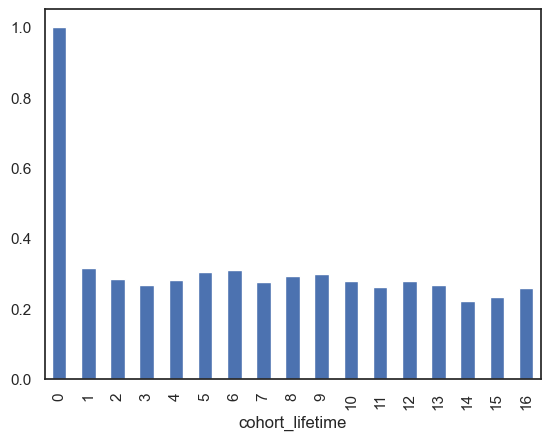

In [137]:

def printRetentionRate(df):
    cohorts = (
        df.groupby(['first_coffee_week', 'cohort_lifetime'], as_index=False)
        .agg({'user_id': 'nunique'})
        .sort_values(['first_coffee_week', 'cohort_lifetime'])
    )


    inital_users_count = cohorts[cohorts['cohort_lifetime'] == 0][
        ['first_coffee_week', 'user_id']
    ]
    inital_users_count = inital_users_count.rename(
        columns={'user_id': 'cohort_users'}
    )

    cohorts = cohorts.merge(inital_users_count, on='first_coffee_week')

    cohorts['retention'] = cohorts['user_id'] / cohorts['cohort_users']

    print(cohorts.groupby(['cohort_lifetime'])['retention'].mean())
    cohorts.groupby(['cohort_lifetime'])['retention'].mean().plot.bar()

printRetentionRate(events.query('is_in_behavioral_cohort == "no" '))

### 6 - 6

Вызовите функцию printRetentionRate(), чтобы вывести данные о среднем Retention Rate по lifetime среди клиентов, попавших в поведенческую когорту клиентов. То есть тех, кто купил кофе более 4 раз в первые 30 дней.

cohort_lifetime
0     1.000000
1     0.762075
2     0.713905
3     0.751156
4     0.570650
5     0.417797
6     0.403484
7     0.355798
8     0.308560
9     0.341140
10    0.462975
11    0.344382
12    0.328101
13    0.253526
14    0.276984
15    0.475000
16    0.500000
Name: retention, dtype: float64


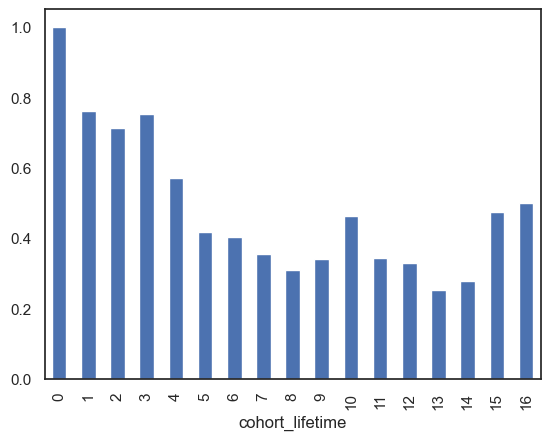

: 

In [138]:
printRetentionRate(events.query('is_in_behavioral_cohort == "yes"'))